# Baseline Models for Team Rho
**Author:** J. Casey Brookshier  
**Date:** July 31, 2026

### Objective:
Establish a benchmark model to determine how well the engineered Google Trends features predict future psychiatric admission rates before testing more advanced models.



In [3]:
import os

print(os.getcwd())
print(os.path.exists(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project.cb/data/processed"
))

/Users/caseybrookshier
True


Train shape: (227, 9)
Test shape: (133, 9)

Columns:
['State', 'Year', 'admission_rate_per_100k', 'admission_rate_lag2', 'neighbor_admission_rate_lag1', 'search_PC1', 'search_PC2', 'search_PC3', 'log_state_population']

Final feature count:
51
Chronologically ordered: True
CV RMSE by fold: [174.21250904  29.87966013  67.21914215  46.28540211  46.80993154]
Mean CV RMSE: 72.88 ± 52.03

Training
--------------------
RMSE: 38.035
MAE : 23.614
R²  : 0.936

Testing
--------------------
RMSE: 53.983
MAE : 41.966
R²  : 0.829

Overfitting Check
--------------------
Training R²: 0.9361847980065403
Testing R²: 0.82936102965542


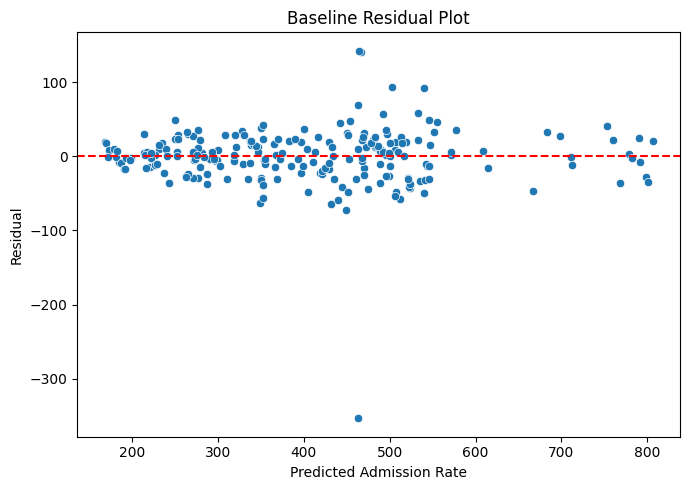

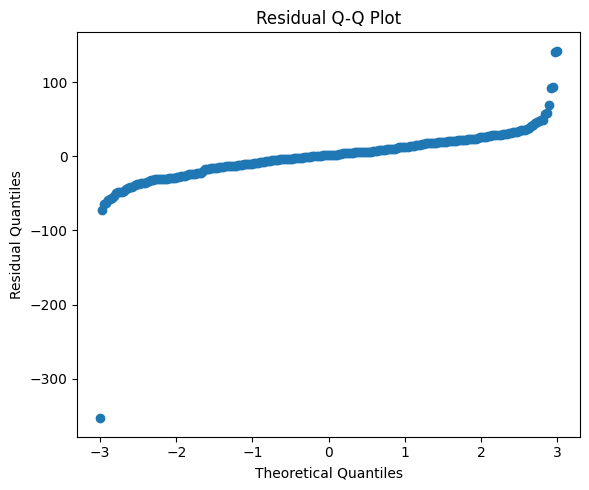


Residual mean: -2.444342134475794e-11
Residual std: 38.03479944140497
Durbin-Watson: 1.766700991073658

Top Coefficients
                Variable   Coefficient
0              Intercept -15587.097891
9       State_California  -4696.968890
44           State_Texas  -4399.420222
12         State_Florida  -3801.677836
33        State_New York  -3519.754921
13         State_Georgia  -3203.463808
39    State_Pennsylvania  -3203.352102
15        State_Illinois  -3118.751007
24        State_Michigan  -3105.695043
34  State_North Carolina  -3088.365549
36            State_Ohio  -3083.124017
48      State_Washington  -2848.000961
31      State_New Jersey  -2810.892506
47        State_Virginia  -2793.375916
7          State_Arizona  -2764.350230
43       State_Tennessee  -2588.251842
16         State_Indiana  -2544.282471
23   State_Massachusetts  -2470.791822
10        State_Colorado  -2463.044278
50       State_Wisconsin  -2415.867734

Saved baseline outputs:
/Users/caseybrookshier/Desktop/Dat

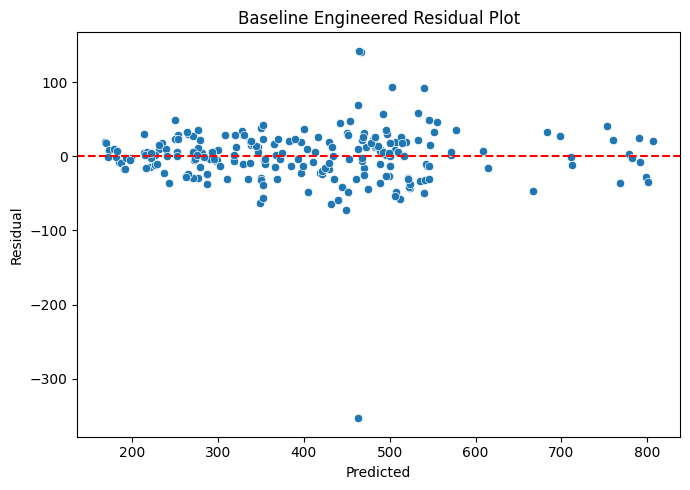

In [4]:
# Baseline Linear Regression Model
# Team Rho Capstone Project

# Objective:
# Establish benchmark performance using engineered temporal,
# spatial, population, and Google Trends PCA features.



import os
from pathlib import Path

# Disable pandas optional compiled dependencies
os.environ["PANDAS_USE_BOTTLENECK"] = "0"
os.environ["PANDAS_USE_NUMEXPR"] = "0"


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# load engineered train/test datasets

DATA_DIR = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2"
)


TRAIN_FILE = (
    DATA_DIR /
    "team_rho_train_preprocessed_engineered_v2.csv"
)


TEST_FILE = (
    DATA_DIR /
    "team_rho_test_preprocessed_engineered_v2.csv"
)


train = pd.read_csv(TRAIN_FILE)

test = pd.read_csv(TEST_FILE)



print("Train shape:", train.shape)

print("Test shape:", test.shape)


print("\nColumns:")
print(train.columns.tolist())


train.head()


# define target and predictors

target = "admission_rate_per_100k"


X_train = train.drop(
    columns=[target]
)

y_train = train[target]


X_test = test.drop(
    columns=[target]
)

y_test = test[target]



# remove year to prevent temporal leakage.

X_train = X_train.drop(
    columns=["Year"]
)


X_test = X_test.drop(
    columns=["Year"]
)


# state fixed effects


X_train = pd.get_dummies(
    X_train,
    columns=["State"],
    drop_first=True,
    dtype=float
)


X_test = pd.get_dummies(
    X_test,
    columns=["State"],
    drop_first=True,
    dtype=float
)



# ensure identical feature columns

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)



print("\nFinal feature count:")
print(X_train.shape[1])


# helper functions RMSE, MAE, R^2, durbin-watson

def rmse(y, pred):

    return np.sqrt(
        np.mean(
            (y-pred)**2
        )
    )



def mae(y, pred):

    return np.mean(
        np.abs(y-pred)
    )



def r2_score_numpy(y, pred):

    ss_res = np.sum(
        (y-pred)**2
    )

    ss_tot = np.sum(
        (y-y.mean())**2
    )

    return 1 - (
        ss_res / ss_tot
    )



def durbin_watson_numpy(residuals):

    diff = np.diff(
        residuals
    )

    return (
        np.sum(diff**2)
        /
        np.sum(residuals**2)
    )

# linear regression using NumPy
# ordinary least squares:
# beta = (X'X)^-1 X'y

def fit_linear_model(X, y):

    X_matrix = np.column_stack(
        [
            np.ones(len(X)),
            X.values
        ]
    )


    beta = np.linalg.lstsq(
        X_matrix,
        y.values,
        rcond=None
    )[0]


    return beta



def predict_linear_model(X, beta):

    X_matrix = np.column_stack(
        [
            np.ones(len(X)),
            X.values
        ]
    )


    return X_matrix @ beta



# fit baseline model

beta = fit_linear_model(
    X_train,
    y_train
)




# 5-FOLD expanding window time series cross validation


# sort observations chronologically
train = train.sort_values(
    ["Year", "State"]
).reset_index(drop=True)

# rebuild target and predictors after sorting
X_train = train.drop(columns=[target, "Year"])

y_train = train[target]

# state fixed effects
X_train = pd.get_dummies(
    X_train,
    columns=["State"],
    drop_first=True,
    dtype=float
)

# align with test
X_test = test.drop(columns=[target, "Year"])

X_test = pd.get_dummies(
    X_test,
    columns=["State"],
    drop_first=True,
    dtype=float
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)


def time_series_cv(X, y, splits=5):

    # leave enough observations for 5 validation periods
    # while ensuring the initial training set exceeds
    # the number of predictors.
    validation_size = 30
    initial_train_size = len(X) - splits * validation_size

    scores = []

    for i in range(splits):

        train_end = (
            initial_train_size +
            i * validation_size
        )

        validation_end = (
            train_end +
            validation_size
        )

        X_tr = X.iloc[:train_end]
        y_tr = y.iloc[:train_end]

        X_val = X.iloc[train_end:validation_end]
        y_val = y.iloc[train_end:validation_end]

        # confirm OLS is not underdetermined
        if len(X_tr) <= X_tr.shape[1]:
            raise ValueError(
                f"Fold {i+1}: "
                f"{len(X_tr)} observations, "
                f"{X_tr.shape[1]} predictors."
            )

        fold_beta = fit_linear_model(
            X_tr,
            y_tr
        )

        pred = predict_linear_model(
            X_val,
            fold_beta
        )

        scores.append(
            rmse(
                y_val.values,
                pred
            )
        )

    return np.array(scores)


cv_rmse = time_series_cv(
    X_train,
    y_train,
    splits=5
)

print("Chronologically ordered:",
      train["Year"].is_monotonic_increasing)

print("CV RMSE by fold:",
      cv_rmse)

print(
    f"Mean CV RMSE: "
    f"{cv_rmse.mean():.2f} ± "
    f"{cv_rmse.std():.2f}"
)
# refit baseline model after chronological sorting
beta = fit_linear_model(
    X_train,
    y_train
)



# predictions

train_pred = predict_linear_model(
    X_train,
    beta
)


test_pred = predict_linear_model(
    X_test,
    beta
)



# evaluation


def evaluate(name,y,pred):

    print("\n" + name)

    print("--------------------")

    print(
        f"RMSE: {rmse(y.values,pred):.3f}"
    )

    print(
        f"MAE : {mae(y.values,pred):.3f}"
    )

    print(
        f"R²  : {r2_score_numpy(y.values,pred):.3f}"
    )



evaluate(
    "Training",
    y_train,
    train_pred
)


evaluate(
    "Testing",
    y_test,
    test_pred
)



# overfitting check

train_r2 = r2_score_numpy(
    y_train.values,
    train_pred
)


test_r2 = r2_score_numpy(
    y_test.values,
    test_pred
)



print("\nOverfitting Check")
print("--------------------")

print(
    "Training R²:",
    train_r2
)

print(
    "Testing R²:",
    test_r2
)



# residual diagnostics

residuals = (
    y_train.values -
    train_pred
)



plt.figure(
    figsize=(7,5)
)


sns.scatterplot(
    x=train_pred,
    y=residuals
)


plt.axhline(
    0,
    color="red",
    linestyle="--"
)


plt.xlabel(
    "Predicted Admission Rate"
)


plt.ylabel(
    "Residual"
)


plt.title(
    "Baseline Residual Plot"
)


plt.tight_layout()

plt.show()



# Q-Q plot

sorted_residuals = np.sort(
    residuals
)


n = len(
    sorted_residuals
)


theoretical = np.linspace(
    -3,
    3,
    n
)



plt.figure(
    figsize=(6,5)
)


plt.scatter(
    theoretical,
    sorted_residuals
)


plt.xlabel(
    "Theoretical Quantiles"
)


plt.ylabel(
    "Residual Quantiles"
)


plt.title(
    "Residual Q-Q Plot"
)


plt.tight_layout()

plt.show()



# approximate normality statistic

residual_mean = residuals.mean()

residual_std = residuals.std()


print(
    "\nResidual mean:",
    residual_mean
)


print(
    "Residual std:",
    residual_std
)


print(
    "Durbin-Watson:",
    durbin_watson_numpy(residuals)
)



# model coefficients

coef = pd.DataFrame(
    {
        "Variable":
            ["Intercept"] + list(X_train.columns),

        "Coefficient":
            beta
    }
)



coef = coef.sort_values(
    "Coefficient",
    key=np.abs,
    ascending=False
)



print(
    "\nTop Coefficients"
)


print(
    coef.head(20)
)


# save outputs

metrics = pd.DataFrame(
    {

        "Dataset":
        [
            "Train",
            "Test"
        ],


        "RMSE":
        [
            rmse(
                y_train.values,
                train_pred
            ),

            rmse(
                y_test.values,
                test_pred
            )
        ],


        "MAE":
        [
            mae(
                y_train.values,
                train_pred
            ),

            mae(
                y_test.values,
                test_pred
            )
        ],


        "R2":
        [
            r2_score_numpy(
                y_train.values,
                train_pred
            ),

            r2_score_numpy(
                y_test.values,
                test_pred
            )
        ]

    }
)



metrics.to_csv(
    DATA_DIR /
    "baseline_engineered_metrics.csv",
    index=False
)



coef.to_csv(
    DATA_DIR /
    "baseline_engineered_coefficients.csv",
    index=False
)



plt.figure(
    figsize=(7,5)
)


sns.scatterplot(
    x=train_pred,
    y=residuals
)


plt.axhline(
    0,
    color="red",
    linestyle="--"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Residual"
)


plt.title(
    "Baseline Engineered Residual Plot"
)


plt.tight_layout()



plt.savefig(
    DATA_DIR /
    "baseline_engineered_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)



print("\nSaved baseline outputs:")

print(
    DATA_DIR /
    "baseline_engineered_metrics.csv"
)

print(
    DATA_DIR /
    "baseline_engineered_coefficients.csv"
)

print(
    DATA_DIR /
    "baseline_engineered_residual_plot.png"
)

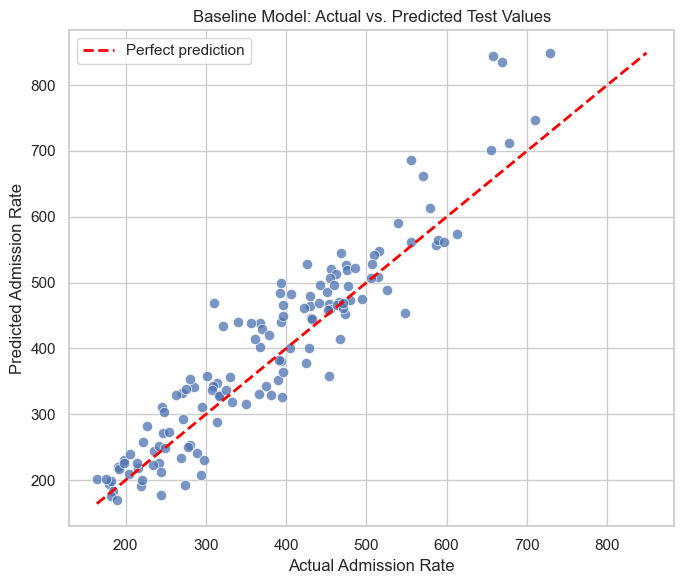

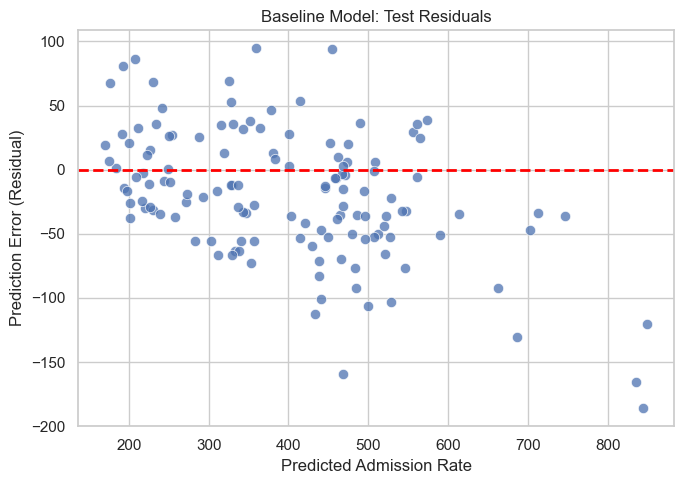

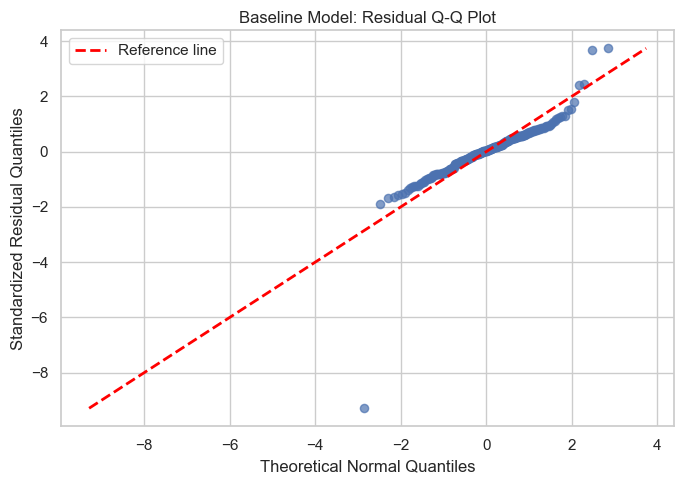

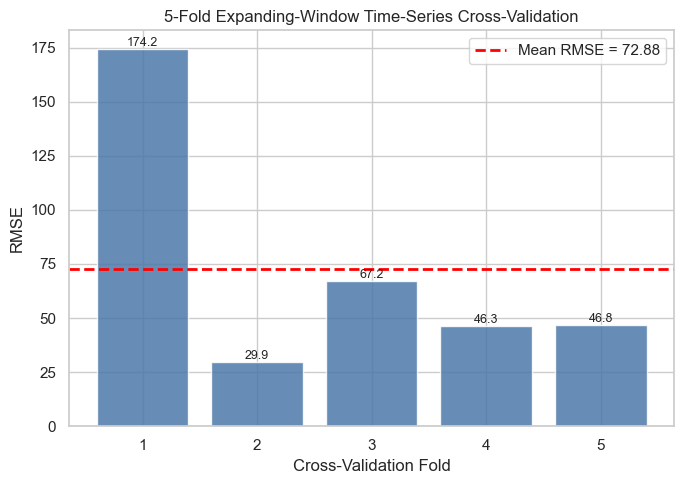


Baseline report outputs saved to:
/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project/Data/processed/Engineered_Data_v2

Graphics:
1. baseline_actual_vs_predicted_test.png
2. baseline_test_residual_plot.png
3. baseline_residual_qq_plot.png
4. baseline_time_series_cv_rmse.png

Tables:
5. baseline_data_dictionary.csv
6. baseline_data_dictionary.html
7. baseline_report_metrics.csv


In [5]:
# baseline outputs

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# output directory

OUTPUT_DIR = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/Team-Rho-Capstone-Project/"
    "Data/processed/Engineered_Data_v2"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# actual vs. predicted test data
# shows how closely predictions match actual admission rates
# on unseen data. 

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test.values,
    y=test_pred,
    s=55,
    alpha=0.75
)

# perfect-prediction reference line
min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Admission Rate")
plt.ylabel("Predicted Admission Rate")
plt.title("Baseline Model: Actual vs. Predicted Test Values")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "baseline_actual_vs_predicted_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# residual plot test data
# checks whether prediction errors show an obvious pattern.


test_residuals = y_test.values - test_pred

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=test_pred,
    y=test_residuals,
    s=55,
    alpha=0.75
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Admission Rate")
plt.ylabel("Prediction Error (Residual)")
plt.title("Baseline Model: Test Residuals")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "baseline_test_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Q-Q plot
# checks whether residuals are approximately normally distributed

sorted_residuals = np.sort(residuals)

n = len(sorted_residuals)

# plotting positions
probabilities = (
    np.arange(1, n + 1) - 0.5
) / n

# standard normal inverse CDF
theoretical_quantiles = (
    np.sqrt(2)
    * np.erfinv(2 * probabilities - 1)
    if hasattr(np, "erfinv")
    else None
)

# NumPy versions without erfinv:
# use a simple fallback based on the existing normal approximation
if theoretical_quantiles is None:
    # approximate inverse normal quantiles using scipy if available
    try:
        from scipy.stats import norm
        theoretical_quantiles = norm.ppf(probabilities)
    except ImportError:
        # if scipy is unavailable, keep the original
        # evenly spaced approximation.
        theoretical_quantiles = np.linspace(-3, 3, n)

# standardize residuals for Q-Q comparison
standardized_residuals = (
    sorted_residuals - np.mean(sorted_residuals)
) / np.std(sorted_residuals)

plt.figure(figsize=(7, 5))

plt.scatter(
    theoretical_quantiles,
    standardized_residuals,
    s=35,
    alpha=0.7
)

# reference line
q_min = min(
    theoretical_quantiles.min(),
    standardized_residuals.min()
)

q_max = max(
    theoretical_quantiles.max(),
    standardized_residuals.max()
)

plt.plot(
    [q_min, q_max],
    [q_min, q_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Reference line"
)

plt.xlabel("Theoretical Normal Quantiles")
plt.ylabel("Standardized Residual Quantiles")
plt.title("Baseline Model: Residual Q-Q Plot")
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "baseline_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# time series cross validation RMSE by fold
# shows how forecasting performance changes across time.

cv_folds = np.arange(1, len(cv_rmse) + 1)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    cv_folds,
    cv_rmse,
    color="#4C78A8",
    alpha=0.85
)

plt.axhline(
    cv_rmse.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean RMSE = {cv_rmse.mean():.2f}"
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Expanding-Window Time-Series Cross-Validation")
plt.xticks(cv_folds)
plt.legend()

# add values above bars
for bar, value in zip(bars, cv_rmse):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "baseline_time_series_cv_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# baseline data dictionary
# generate directly from the current engineered data
# reload current engineered data

train_current = pd.read_csv(TRAIN_FILE)
test_current = pd.read_csv(TEST_FILE)

all_data = pd.concat(
    [
        train_current.assign(_dataset="Training"),
        test_current.assign(_dataset="Testing")
    ],
    ignore_index=True
)

# concise descriptions based on the project's variables
variable_descriptions = {
    "State":
        "U.S. state associated with the observation.",

    "Year":
        "Calendar year of the observation.",

    "admission_rate_per_100k":
        "Psychiatric admission rate per 100,000 population; model target.",

    "admission_rate_lag2":
        "Psychiatric admission rate from two years earlier.",

    "neighbor_admission_rate_lag1":
        "Previous-year psychiatric admission rate among neighboring states.",

    "search_PC1":
        "First principal component summarizing Google Trends search activity.",

    "search_PC2":
        "Second principal component summarizing Google Trends search activity.",

    "search_PC3":
        "Third principal component summarizing Google Trends search activity.",

    "log_state_population":
        "Natural-log-transformed state population."
}

dictionary_rows = []

for column in all_data.columns:

    if column == "_dataset":
        continue

    series = all_data[column]

    # numeric information
    if pd.api.types.is_numeric_dtype(series):

        min_value = series.min()
        max_value = series.max()
        mean_value = series.mean()

        range_text = (
            f"{min_value:.4f} to {max_value:.4f}"
        )

        mean_text = f"{mean_value:.4f}"

    else:

        min_value = ""
        max_value = ""
        mean_text = ""

        # avoid printing large category lists
        if series.nunique(dropna=True) <= 10:
            range_text = ", ".join(
                map(
                    str,
                    sorted(
                        series.dropna().unique()
                    )
                )
            )
        else:
            range_text = (
                f"{series.nunique(dropna=True)} unique values"
            )

    dictionary_rows.append(
        {
            "Variable": column,
            "Description": variable_descriptions.get(
                column,
                "Engineered predictor; see preprocessing documentation."
            ),
            "Data Type": str(series.dtype),
            "Non-Missing": int(series.notna().sum()),
            "Missing": int(series.isna().sum()),
            "Unique Values": int(series.nunique(dropna=True)),
            "Range / Categories": range_text,
            "Mean (numeric)": mean_text
        }
    )

data_dictionary = pd.DataFrame(dictionary_rows)

# save CSV
data_dictionary.to_csv(
    OUTPUT_DIR / "baseline_data_dictionary.csv",
    index=False
)

# save HTML 
data_dictionary.to_html(
    OUTPUT_DIR / "baseline_data_dictionary.html",
    index=False,
    border=0
)


# save report metrics summary

report_metrics = pd.DataFrame(
    {
        "Metric": [
            "Training observations",
            "Testing observations",
            "Number of predictors",
            "Training RMSE",
            "Training MAE",
            "Training R²",
            "Testing RMSE",
            "Testing MAE",
            "Testing R²",
            "CV mean RMSE",
            "CV RMSE standard deviation",
            "Residual mean",
            "Durbin-Watson"
        ],
        "Value": [
            len(train_current),
            len(test_current),
            X_train.shape[1],
            rmse(y_train.values, train_pred),
            mae(y_train.values, train_pred),
            r2_score_numpy(y_train.values, train_pred),
            rmse(y_test.values, test_pred),
            mae(y_test.values, test_pred),
            r2_score_numpy(y_test.values, test_pred),
            cv_rmse.mean(),
            cv_rmse.std(),
            residuals.mean(),
            durbin_watson_numpy(residuals)
        ]
    }
)

report_metrics.to_csv(
    OUTPUT_DIR / "baseline_report_metrics.csv",
    index=False
)


# final output list

print("\nBaseline report outputs saved to:")
print(OUTPUT_DIR)

print("\nGraphics:")
print("1. baseline_actual_vs_predicted_test.png")
print("2. baseline_test_residual_plot.png")
print("3. baseline_residual_qq_plot.png")
print("4. baseline_time_series_cv_rmse.png")

print("\nTables:")
print("5. baseline_data_dictionary.csv")
print("6. baseline_data_dictionary.html")
print("7. baseline_report_metrics.csv")